In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [3]:
wine_quality = pd.read_csv('winequalityN.csv')

In [12]:
wine_quality.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.216579,0.339691,0.318722,5.444326,0.056042,30.525319,115.744574,0.994697,3.218395,0.531215,10.491801,5.818378
std,1.295751,0.164548,0.145231,4.757392,0.035031,17.749400,56.521855,0.002999,0.160637,0.148768,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [6]:
wine_quality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [7]:
wine_quality.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [8]:
wine_quality.isnull().sum()

type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
dtype: int64

In [10]:
for col in wine_quality.columns:
  if wine_quality[col].isnull().sum() > 0:
    wine_quality[col] = wine_quality[col].fillna(wine_quality[col].mean())

In [13]:
wine_quality.isnull().sum().sum()

0

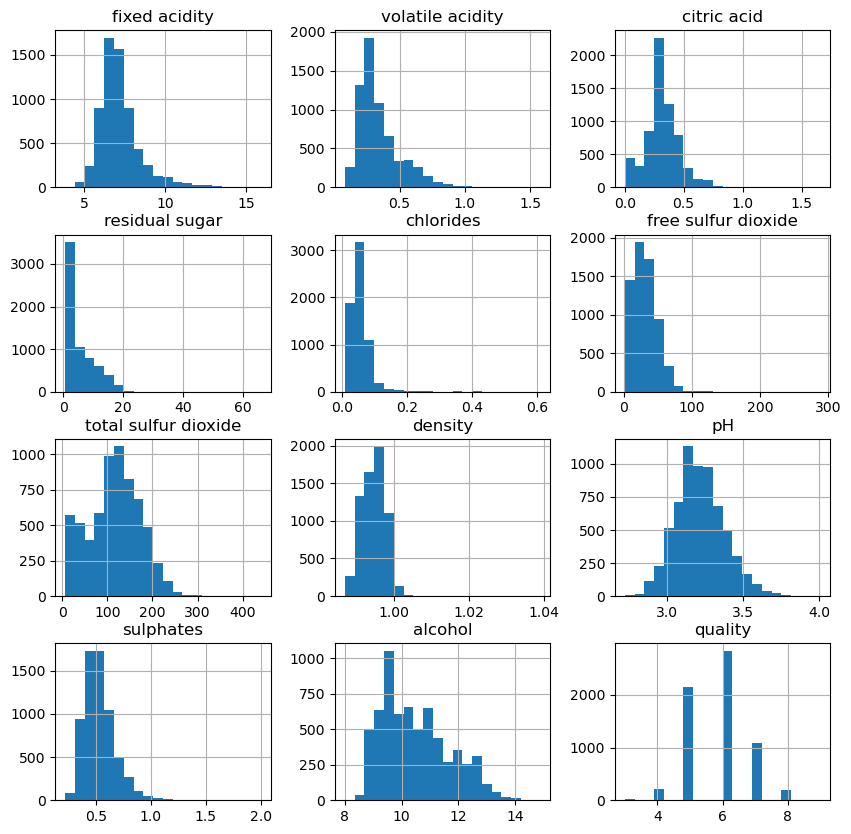

In [14]:
wine_quality.hist(bins=20, figsize=(10, 10))
plt.show()


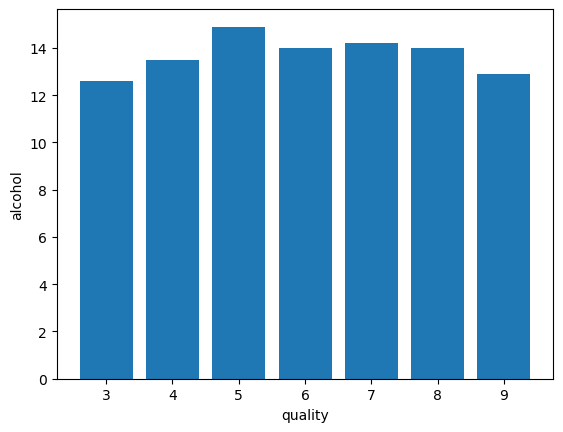

In [19]:
plt.bar(wine_quality['quality'], wine_quality['alcohol'])
plt.xlabel('quality')
plt.ylabel('alcohol')
plt.show()

In [21]:
# Convert 'object' columns to numerical if they represent numbers
for col in wine_quality.columns:
    if wine_quality[col].dtype == 'object':
        try:
            wine_quality[col] = pd.to_numeric(wine_quality[col], errors='coerce')  # Convert to numeric, replace non-convertibles with NaN
        except:
            pass  # Skip columns that cannot be converted

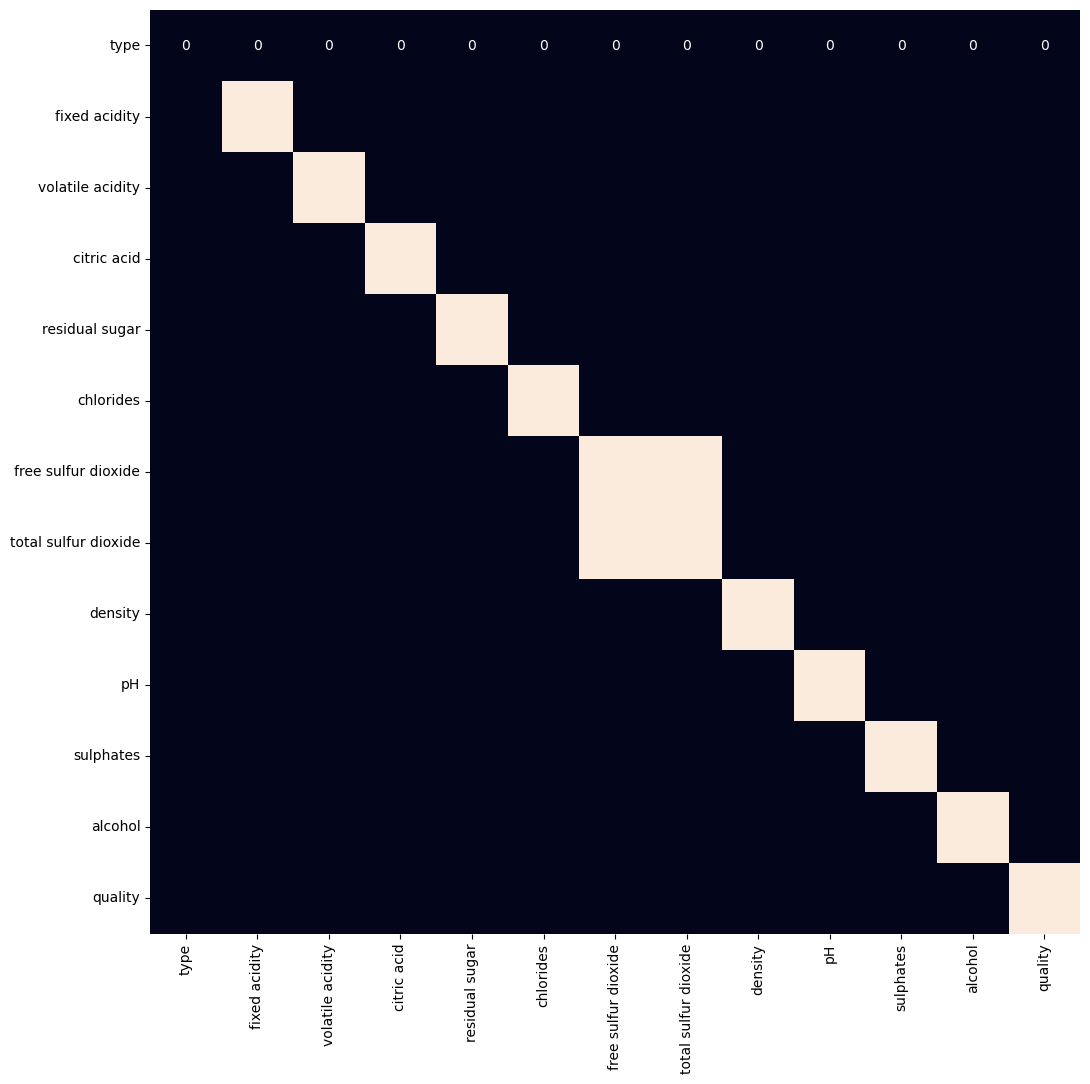

In [24]:
plt.figure(figsize=(12, 12))
sns.heatmap(wine_quality.corr() > 0.7, annot=True, cbar=False)
plt.show()

In [25]:
wine_quality = wine_quality.drop('total sulfur dioxide', axis=1)

In [26]:
wine_quality['best quality'] = [1 if x > 5 else 0 for x in wine_quality.quality]

In [27]:
wine_quality.replace({'white': 1, 'red': 0}, inplace=True)

In [30]:
features = wine_quality.drop(['quality', 'best quality'], axis=1)

In [31]:
features = features.fillna(features.mean())

In [32]:
target = wine_quality['best quality']

In [33]:
xtrain, xtest, ytrain, ytest = train_test_split(
    features, target, test_size=0.2, random_state=40
)

In [34]:
# Impute missing values after splitting
from sklearn.impute import SimpleImputer

In [35]:
imputer = SimpleImputer(strategy='mean')  # Or another strategy like 'median'
xtrain = imputer.fit_transform(xtrain)
xtest = imputer.transform(xtest)

C:\Users\Dell\AppData\Roaming\Python\Python311\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['type']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
C:\Users\Dell\AppData\Roaming\Python\Python311\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['type']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [36]:
xtrain.shape, xtest.shape

((5197, 10), (1300, 10))

In [37]:
norm = MinMaxScaler()
xtrain = norm.fit_transform(xtrain)
xtest = norm.transform(xtest)

In [38]:
logistic_model = LogisticRegression()
xgb_model = XGBClassifier()
svc_model = SVC(kernel='rbf')

In [44]:
models = [logistic_model, xgb_model, svc_model]
for model in models:
    model.fit(xtrain, ytrain)
    
for model in models:
    model_name = model.__class__.__name__
    print(f'{model_name} : ')

 # Training Accuracy
    train_preds = model.predict(xtrain)
    train_accuracy = metrics.roc_auc_score(ytrain, train_preds)
    print(f'Training Accuracy : {train_accuracy}')
    
    test_preds = model.predict(xtest)
    test_accuracy = metrics.roc_auc_score(ytest, test_preds)
    print(f'Validation Accuracy : {test_accuracy}')
    print('-' * 50)

LogisticRegression : 
Training Accuracy : 0.6968344278667192
Validation Accuracy : 0.6865607216926675
--------------------------------------------------
XGBClassifier : 
Training Accuracy : 0.9746285940011181
Validation Accuracy : 0.7976496970811495
--------------------------------------------------
SVC : 
Training Accuracy : 0.7203202525576721
Validation Accuracy : 0.7073819229472522
--------------------------------------------------


In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

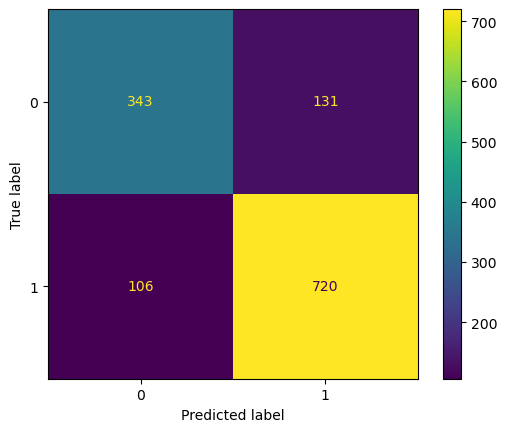

In [46]:
cm = confusion_matrix(ytest, models[1].predict(xtest))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=models[1].classes_) # Assuming your model has a 'classes_' attribute
disp.plot()
plt.show()

In [47]:
print(metrics.classification_report(ytest,
									models[1].predict(xtest)))

              precision    recall  f1-score   support

           0       0.76      0.72      0.74       474
           1       0.85      0.87      0.86       826

    accuracy                           0.82      1300
   macro avg       0.80      0.80      0.80      1300
weighted avg       0.82      0.82      0.82      1300

